## 실습 1. 전처리 데이터 불러오기

 

해야 할 일

 

먼저 Chapter 01에서 만든 CSV 파일을 pandas로 불러옵니다.

 

처음부터 단어를 분리하지 말고 데이터가 정상적으로 연결되는지 먼저 확인합니다.

In [1]:
import pandas as pd

# CSV 파일 불러오기 (인코딩: utf-8-sig)
df_books = pd.read_csv('book_bestseller_clean.csv', encoding='utf-8-sig')

# 1. 전체 행과 컬럼 개수
print(df_books.shape)

# 2. 컬럼 이름
print(df_books.columns)

# 3. 앞의 5행
print(df_books.head())

# 4. '상품명' 컬럼이 존재하는지 확인
print('상품명' in df_books.columns)

(989, 8)
Index(['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야'], dtype='str')
   순위         판매상품ID                    상품명    판매가      저자      출판사  \
0   1  S000220308313  세네카, 오늘을 빼앗기고 있는 당신에게  16200     세네카      논픽션   
1   2  S000221143299           홍정기의 장수근육 혁명  17820     홍정기        깸   
2   3  S000000620195                   싯다르타   7200  헤르만 헤세      민음사   
3   4  S000221075112            머니 트렌드 2027  24750   정태익 외     북모먼트   
4   5  S000221248222                흔한남매 23  15120    흔한남매  미래엔아이세움   

          발행일       분야  
0  2026-07-01       인문  
1  2026-08-31       건강  
2  2002-01-20       소설  
3  2026-09-16    경제/경영  
4  2026-09-16  어린이(초등)  
True


## 결과 검증

| 확인 항목 | 결과 |
| --- | --- |
| CSV 파일이 정상적으로 열렸는가? | 예 — 오류 없이 `df_books`로 로드됨 |
| 행 개수가 Chapter 01 결과와 크게 달라지지 않았는가? | 989행 — Chapter 01에서 저장한 행 수와 비교해서 확인 필요 |
| 상품명 컬럼이 존재하는가? | 예 — 컬럼 목록에 `상품명` 포함 (`'상품명' in df_books.columns` → True) |
| 상품명이 한글로 정상적으로 보이는가? | 예 — 깨짐 없이 정상 표시됨 (`utf-8-sig` 인코딩 적용) |

## 실습 2. 분석할 도서 제목 확인하기

 

단어 분석을 시작하기 전에 상품명 데이터가 어떤 형태인지 직접 확인합니다.

In [2]:
df_books["상품명"].head(20)

0                                세네카, 오늘을 빼앗기고 있는 당신에게
1                                         홍정기의 장수근육 혁명
2                                                 싯다르타
3                                          머니 트렌드 2027
4                                              흔한남매 23
5            2026 해커스 투자자산운용사 실전동형모의고사 10회분+리얼 기출족보 3종
6                                       시대예보: 수고인류의 시간
7                                    리더는 언제 차이를 만들어내는가
8                                               판매의 법칙
9                                              니체의 초월자
10                                        군주론 : 쇼츠 에디션
11                                   한국사 이상현상 연구원(일반판)
12                         2027 해커스경찰 갓대환 형사법 기출총정리 세트
13                                                  테오
14                          쇼펜하우어 인생수업(30만 부 기념 개정증보판)
15                                             마음의 어휘력
16                                                  모순
17    2026 큰별쌤 최태성의 별별한국사 기출 500제 한국사능력검정시험 심화(1,2,3급)
18        

In [3]:
df_books["상품명"].isna().sum()

np.int64(0)

In [4]:
titles = (

    df_books["상품명"]

    .fillna("")

    .astype(str)

    .str.strip()

)

titles.head()

0    세네카, 오늘을 빼앗기고 있는 당신에게
1             홍정기의 장수근육 혁명
2                     싯다르타
3              머니 트렌드 2027
4                  흔한남매 23
Name: 상품명, dtype: str

In [5]:
titles = titles[titles != ""]

print("사용할 제목 개수:", len(titles))

사용할 제목 개수: 989


## 실습 3. Dictionary로 단어 빈도 원리 이해하기

 

빈도 분석의 핵심은 매우 단순합니다.

 

같은 단어가 등장할 때마다 해당 단어의 숫자를 1씩 증가시키면 됩니다.

 

예를 들어 다음 단어가 있다고 가정합니다.

In [6]:

sample_words = [

    "데이터",

    "분석",

    "파이썬",

    "데이터",

    "AI",

    "분석",

    "데이터",

]

word_counts = {}
for word in sample_words:
    if word in word_counts:
        word_counts[word] += 1
    else:
        word_counts[word] = 1

print(word_counts)

{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


## 실습 4. Counter로 같은 작업 간단하게 처리하기

Python에는 빈도 계산을 도와주는 Counter가 있습니다.


In [7]:
from collections import Counter

sample_counter = Counter(sample_words)

print(sample_counter)


Counter({'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1})


In [8]:
sample_counter.most_common()

[('데이터', 3), ('분석', 2), ('파이썬', 1), ('AI', 1)]

In [9]:
sample_counter.most_common(3)


[('데이터', 3), ('분석', 2), ('파이썬', 1)]

## 실습 5. pandas value_counts()로 빈도 확인하기

pandas에서도 같은 값이 몇 번 등장했는지 쉽게 확인할 수 있습니다.


In [10]:

sample_series = pd.Series(sample_words)

sample_series.value_counts()


데이터    3
분석     2
파이썬    1
AI     1
Name: count, dtype: int64

## 실습 6. 실제 도서 제목을 간단하게 단어로 나누기

이제 실제 상품명 데이터를 사용합니다.

한글 형태소 분석을 사용하기 전에 먼저 정규표현식을 이용해 단순한 토큰화를 해봅니다.

이번 단계의 목적은 완벽한 단어 추출이 아니라 실제 데이터에서도 빈도 집계 흐름이 어떻게 연결되는지 확인하는 것입니다.


In [11]:

import re

def simple_tokenize(text):

    return re.findall(r"[가-힣A-Za-z0-9]+", str(text).lower())

In [12]:

sample_title = "AI 시대의 데이터 분석, Python으로 시작하기!"

simple_tokenize(sample_title)

['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']

## 실습 7. 모든 제목에서 단어 추출하기

먼저 단순 토큰화 방식으로 모든 제목의 단어를 하나의 리스트에 모아봅니다.


In [13]:

simple_words = []

for title in titles:

    words = simple_tokenize(title)

    simple_words.extend(words)

print("전체 단어 수:", len(simple_words))

print(simple_words[:50])

전체 단어 수: 4247
['세네카', '오늘을', '빼앗기고', '있는', '당신에게', '홍정기의', '장수근육', '혁명', '싯다르타', '머니', '트렌드', '2027', '흔한남매', '23', '2026', '해커스', '투자자산운용사', '실전동형모의고사', '10회분', '리얼', '기출족보', '3종', '시대예보', '수고인류의', '시간', '리더는', '언제', '차이를', '만들어내는가', '판매의', '법칙', '니체의', '초월자', '군주론', '쇼츠', '에디션', '한국사', '이상현상', '연구원', '일반판', '2027', '해커스경찰', '갓대환', '형사법', '기출총정리', '세트', '테오', '쇼펜하우어', '인생수업', '30만']


In [14]:
example = []
example.append(["데이터", "분석"])
print(example)

[['데이터', '분석']]


In [15]:
example = []
example.extend(["데이터", "분석"])
print(example)

['데이터', '분석']


 ## 실습 8. 실제 데이터에서 Counter로 빈도 확인하기


In [16]:

simple_counter = Counter(simple_words)

simple_counter.most_common(30)

[('2027', 93),
 ('2026', 57),
 ('1', 39),
 ('해커스', 38),
 ('기본서', 30),
 ('2', 28),
 ('세트', 25),
 ('에디션', 22),
 ('기출문제집', 21),
 ('토익', 20),
 ('the', 18),
 ('기념', 17),
 ('끝내는', 16),
 ('해커스경찰', 15),
 ('한', 15),
 ('모의고사', 15),
 ('ai', 15),
 ('2026년', 15),
 ('해커스공무원', 14),
 ('초판본', 14),
 ('부', 13),
 ('ncs', 13),
 ('공단기', 13),
 ('rc', 12),
 ('lc', 12),
 ('통합', 12),
 ('실전모의고사', 12),
 ('읽는', 12),
 ('공무원', 11),
 ('영어', 11)]

In [17]:
simple_top30 = pd.DataFrame(
    simple_counter.most_common(30),
    columns=["단어", "빈도"]
)
simple_top30


,단어,빈도
0,2027,93
1,2026,57
2,1,39
3,해커스,38
4,기본서,30
5,2,28
6,세트,25
7,에디션,22
8,기출문제집,21
9,토익,20


## 실습 9. pandas로도 실제 단어 빈도 확인하기


In [18]:
simple_word_series = pd.Series(simple_words)

simple_word_series.value_counts().head(30)


2027      93
2026      57
1         39
해커스       38
기본서       30
2         28
세트        25
에디션       22
기출문제집     21
토익        20
the       18
기념        17
끝내는       16
해커스경찰     15
한         15
모의고사      15
ai        15
2026년     15
해커스공무원    14
초판본       14
부         13
ncs       13
공단기       13
rc        12
lc        12
통합        12
실전모의고사    12
읽는        12
공무원       11
영어        11
Name: count, dtype: int64

In [19]:
print(simple_counter.most_common(10))

print(simple_word_series.value_counts().head(10))

[('2027', 93), ('2026', 57), ('1', 39), ('해커스', 38), ('기본서', 30), ('2', 28), ('세트', 25), ('에디션', 22), ('기출문제집', 21), ('토익', 20)]
2027     93
2026     57
1        39
해커스      38
기본서      30
2        28
세트       25
에디션      22
기출문제집    21
토익       20
Name: count, dtype: int64


## 실습 10. 왜 형태소 분석이 필요한가?

한국어는 단순히 공백만 기준으로 단어를 나누기 어렵습니다.


## 실습 11. Kiwi 형태소 분석기 설치하기


 

예를 들어 다음과 같은 표현을 생각해 봅니다.


한글 형태소 분석 도구는 여러 가지가 있습니다.

 

이번 실습에서는 Windows 환경에서도 비교적 설치가 간단한 kiwipiepy를 사용합니다.

 

터미널에서 현재 사용하는 Python 가상환경이 활성화되어 있는지 확인한 뒤 설치합니다.


## 실습 12. Kiwi로 한 문장 품사 확인하기
설치 후 먼저 짧은 문장을 테스트합니다.

In [20]:
from kiwipiepy import Kiwi
kiwi = Kiwi()
sample_title = "AI 시대의 데이터 분석을 위한 파이썬"
tokens = kiwi.tokenize(sample_title)
tokens

[Token(form='AI', tag='SL', start=0, len=2),
 Token(form='시대', tag='NNG', start=3, len=2),
 Token(form='의', tag='JKG', start=5, len=1),
 Token(form='데이터', tag='NNG', start=7, len=3),
 Token(form='분석', tag='NNG', start=11, len=2),
 Token(form='을', tag='JKO', start=13, len=1),
 Token(form='위하', tag='VV', start=15, len=2),
 Token(form='ᆫ', tag='ETM', start=16, len=1),
 Token(form='파이썬', tag='NNP', start=18, len=3)]

In [21]:
for token in tokens:
    print(token.form, token.tag)


AI SL
시대 NNG
의 JKG
데이터 NNG
분석 NNG
을 JKO
위하 VV
ᆫ ETM
파이썬 NNP


## 실습 13. 명사 중심으로 단어 추출하기

In [22]:
TARGET_TAGS = {"NNG", "NNP", "SL"}

def extract_words(text):

    result = []

    for token in kiwi.tokenize(str(text)):

        if token.tag in TARGET_TAGS:

            word = token.form.strip().lower()

            result.append(word)

    return result

In [23]:
extract_words("AI 시대의 데이터 분석을 위한 파이썬")

['ai', '시대', '데이터', '분석', '파이썬']

## 실습 14. 최소 글자수 필터링 적용하기

 

한 글자 단어가 모두 의미 없는 것은 아닙니다.

 

하지만 도서 제목 빈도 분석에서는 한 글자 토큰이 지나치게 많이 등장하면 결과를 해석하기 어려울 수 있습니다.

 

먼저 실제 결과를 확인한 뒤 이번 실습에서는 기본적으로 2글자 이상을 사용해 봅니다.


In [24]:
MIN_LENGTH = 2

def extract_words(text):
    result = []
    for token in kiwi.tokenize(str(text)):
        if token.tag in TARGET_TAGS:
            word = token.form.strip().lower()
            if len(word) >= MIN_LENGTH:
                result.append(word)
    return result


## 실습 15. 모든 도서 제목에서 명사 추출하기

In [25]:

filtered_words = []

for title in titles:

    words = extract_words(title)

    filtered_words.extend(words)

print("추출된 전체 단어 수:", len(filtered_words))

print(filtered_words[:50])

추출된 전체 단어 수: 3139
['세네카', '오늘', '홍정기', '장수', '근육', '혁명', '싯다르타', '머니', '트렌드', '남매', '해커스', '투자', '자산', '운용사', '실전동형', '모의고사', '리얼', '기출', '족보', '시대', '예보', '인류', '시간', '리더', '차이', '판매', '법칙', '니체', '초월자', '군주론', '쇼츠', '에디션', '한국사', '이상', '현상', '연구원', '일반판', '해커스', '경찰', '갓대환', '형사법', '기출', '정리', '세트', '테오', '쇼펜하우어', '인생', '수업', '기념', '개정']


In [27]:

noun_counter = Counter(filtered_words)

noun_counter.most_common(30)

[('해커스', 79),
 ('기출', 58),
 ('기본', 37),
 ('모의고사', 33),
 ('공무원', 27),
 ('토익', 26),
 ('경찰', 25),
 ('세트', 25),
 ('문제집', 25),
 ('에디션', 24),
 ('기념', 24),
 ('실전', 22),
 ('사랑', 20),
 ('일본어', 19),
 ('the', 18),
 ('시험', 17),
 ('통합', 17),
 ('영어', 17),
 ('ncs', 16),
 ('인생', 15),
 ('국어', 15),
 ('핵심', 15),
 ('ai', 15),
 ('수업', 14),
 ('최신', 14),
 ('능력', 14),
 ('초판본', 14),
 ('시대', 13),
 ('유형', 13),
 ('문제', 13)]

In [28]:

noun_top30 = pd.DataFrame(

    noun_counter.most_common(30),

    columns=["단어", "빈도"]

)

noun_top30

,단어,빈도
0,해커스,79
1,기출,58
2,기본,37
3,모의고사,33
4,공무원,27
5,토익,26
6,경찰,25
7,세트,25
8,문제집,25
9,에디션,24


In [29]:

print("단순 토큰화 상위 단어")

display(simple_top30.head(10))

print("형태소 분석 후 상위 단어")

display(noun_top30.head(10))

단순 토큰화 상위 단어


,단어,빈도
0,2027,93
1,2026,57
2,1,39
3,해커스,38
4,기본서,30
5,2,28
6,세트,25
7,에디션,22
8,기출문제집,21
9,토익,20


형태소 분석 후 상위 단어


,단어,빈도
0,해커스,79
1,기출,58
2,기본,37
3,모의고사,33
4,공무원,27
5,토익,26
6,경찰,25
7,세트,25
8,문제집,25
9,에디션,24


## 실습 16. 불용어 이해하기

 

형태소 분석 후에도 분석 목적과 관계가 적은 단어가 상위에 나타날 수 있습니다.

 

예를 들어 실제 데이터를 확인한 뒤 다음과 같은 표현이 반복될 수 있습니다.

## 실습 17. 불용어 목록 만들기

 

처음에는 너무 많은 단어를 넣지 않습니다.

 

예시는 다음과 같습니다.

In [30]:
TARGET_TAGS = {"NNG", "NNP", "SL"}

MIN_LENGTH = 2

STOPWORDS = {

    "세트",

    "개정판",

    "에디션",

    "리커버",

    "한정판",

}

def extract_words(text):

    result = []

    for token in kiwi.tokenize(str(text)):

        if token.tag not in TARGET_TAGS:

            continue

        word = token.form.strip().lower()

        if len(word) < MIN_LENGTH:

            continue

        if word in STOPWORDS:

            continue

        result.append(word)

    return result

## 실습 18. 최종 단어 목록 만들기

 

In [31]:
final_words = []

for title in titles:

    final_words.extend(extract_words(title))

print("최종 단어 수:", len(final_words))

print(final_words[:50])

최종 단어 수: 3073
['세네카', '오늘', '홍정기', '장수', '근육', '혁명', '싯다르타', '머니', '트렌드', '남매', '해커스', '투자', '자산', '운용사', '실전동형', '모의고사', '리얼', '기출', '족보', '시대', '예보', '인류', '시간', '리더', '차이', '판매', '법칙', '니체', '초월자', '군주론', '쇼츠', '한국사', '이상', '현상', '연구원', '일반판', '해커스', '경찰', '갓대환', '형사법', '기출', '정리', '테오', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '마음']


In [32]:

final_counter = Counter(final_words)

final_counter.most_common(30)

[('해커스', 79),
 ('기출', 58),
 ('기본', 37),
 ('모의고사', 33),
 ('공무원', 27),
 ('토익', 26),
 ('경찰', 25),
 ('문제집', 25),
 ('기념', 24),
 ('실전', 22),
 ('사랑', 20),
 ('일본어', 19),
 ('the', 18),
 ('시험', 17),
 ('통합', 17),
 ('영어', 17),
 ('ncs', 16),
 ('인생', 15),
 ('국어', 15),
 ('핵심', 15),
 ('ai', 15),
 ('수업', 14),
 ('최신', 14),
 ('능력', 14),
 ('초판본', 14),
 ('시대', 13),
 ('유형', 13),
 ('문제', 13),
 ('공단기', 13),
 ('투자', 12)]

In [33]:
top30 = pd.DataFrame(

    final_counter.most_common(30),

    columns=["단어", "빈도"]

)

top30

,단어,빈도
0,해커스,79
1,기출,58
2,기본,37
3,모의고사,33
4,공무원,27
5,토익,26
6,경찰,25
7,문제집,25
8,기념,24
9,실전,22


In [34]:

top30.to_csv(

    "chapter02_top30_words.csv",

    index=False,

    encoding="utf-8-sig"

)

In [35]:

from pathlib import Path

Path("chapter02_top30_words.csv").exists()

True

실습 19. 상위 단어를 막대그래프로 먼저 확인하기

 

Word Cloud는 직관적이지만 정확한 빈도 비교에는 막대그래프가 더 편할 수 있습니다.

 

따라서 Word Cloud를 만들기 전에 상위 단어를 간단한 막대그래프로 확인해 봅니다.


C:\Users\sws50\AppData\Local\Temp\ipykernel_10960\4202120436.py:15: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sws50\AppData\Local\Temp\ipykernel_10960\4202120436.py:15: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sws50\AppData\Local\Temp\ipykernel_10960\4202120436.py:15: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sws50\AppData\Local\Temp\ipykernel_10960\4202120436.py:15: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sws50\AppData\Local\Temp\ipykernel_10960\4202120436.py:15: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sws50\AppData\Local\Temp\ipykernel_10960\4202120436.py:15: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from fo

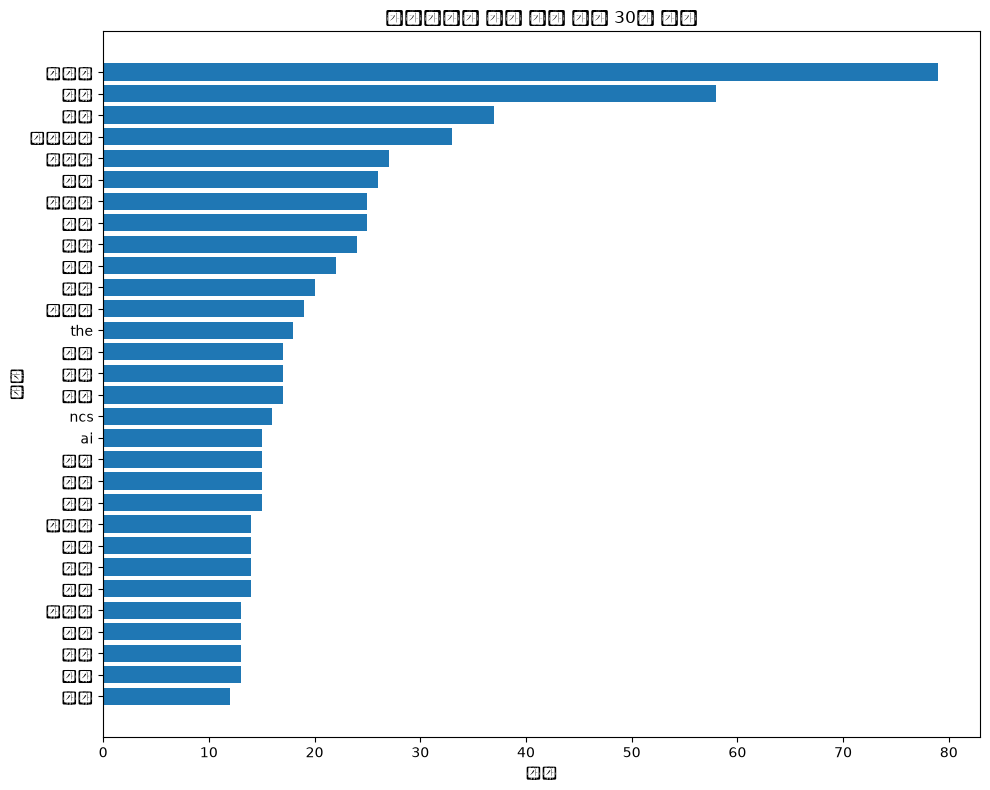

In [36]:

import matplotlib.pyplot as plt

plot_data = top30.sort_values("빈도", ascending=True)

plt.figure(figsize=(10, 8))

plt.barh(plot_data["단어"], plot_data["빈도"])

plt.xlabel("빈도")

plt.ylabel("단어")

plt.title("베스트셀러 도서 제목 상위 30개 단어")

plt.tight_layout()

plt.show()

In [37]:

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False

## 실습 20. Word Cloud 설치하기

 

Word Cloud 라이브러리가 없다면 현재 가상환경에 설치합니다.

In [38]:
from wordcloud import WordCloud

## 실습 21. Word Cloud용 한글 폰트 확인하기

 

Word Cloud에서 한글을 정상적으로 표시하려면 한글 폰트 파일 경로가 필요합니다.

 

Windows에서 흔히 사용할 수 있는 맑은 고딕 경로는 다음과 같습니다.

In [39]:
from pathlib import Path

FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")

print(FONT_PATH.exists())

True


## 실습 22. Word Cloud 생성하기

 

Word Cloud는 단어 빈도 Dictionary를 바로 사용할 수 있습니다.

 

Counter도 Dictionary와 유사한 형태로 사용할 수 있습니다.


In [40]:
from wordcloud import WordCloud

wordcloud = WordCloud(

    font_path=str(FONT_PATH),

    width=1200,

    height=700,

    background_color="white",

    max_words=100,

    random_state=42,

).generate_from_frequencies(final_counter)

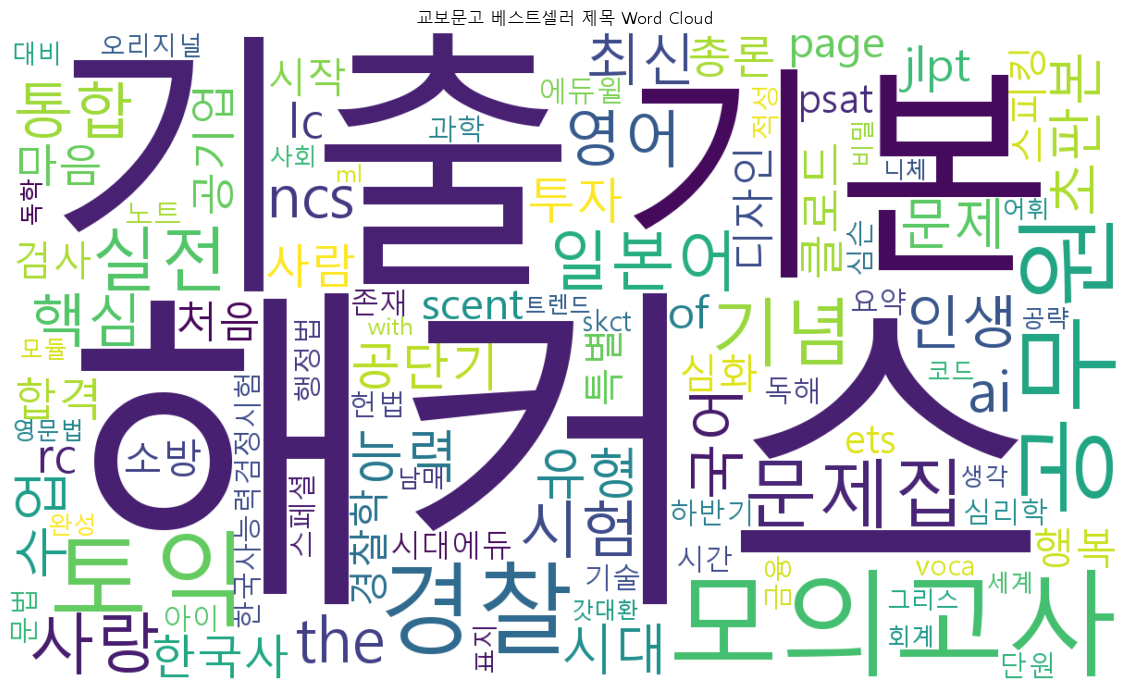

In [41]:
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("교보문고 베스트셀러 제목 Word Cloud")
plt.tight_layout()
plt.show()

In [42]:
wordcloud.to_file("chapter02_wordcloud.png")

In [43]:
Path("chapter02_wordcloud.png").exists()

True

## 실습 23. Word Cloud를 어떻게 해석해야 할까?
Word Cloud에서 글자가 크게 보인다는 것은 이번 분석 조건에서 더 많이 등장했다는 의미입니다.

예를 들어 데이터가 크게 보인다면 다음 정도로 해석할 수 있습니다.


## 실습 24. 상위 단어를 원본 제목에서 다시 확인하기

 

빈도 결과가 맞는지 확인하는 가장 좋은 방법 중 하나는 원본 데이터로 돌아가는 것입니다.

 

예를 들어 상위 단어 중 하나를 선택합니다.

 

In [44]:

target_word = top30.iloc[0]["단어"]

print("확인할 단어:", target_word)

확인할 단어: 해커스


In [45]:

matched_titles = df_books[

    df_books["상품명"].astype(str).str.contains(

        str(target_word),

        case=False,

        na=False,

        regex=False,

    )

][["상품명", "분야"]]

matched_titles.head(20)

,상품명,분야
5,2026 해커스 투자자산운용사 실전동형모의고사 10회분+리얼 기출족보 3종,취업/수험서
12,2027 해커스경찰 갓대환 형사법 기출총정리 세트,취업/수험서
44,해커스 토익 기출 VOCA(보카),외국어
64,2026 해커스 GSAT 삼성직무적성검사 통합 기본서 최신기출유형+실전모의고사 (수...,취업/수험서
72,2027 해커스경찰 신동욱 경찰헌법 기본서,취업/수험서
77,2026 해커스 SKCT SK그룹 종합역량검사 통합 기본서 최신기출유형+실전모의고사,NaN
90,2026 해커스경찰 갓대환 형사법 기본서 2: 형사소송법 수사와 증거,취업/수험서
92,2027 해커스소방 심규식 응급처치학개론 단원별 기출문제집,취업/수험서
99,2027 해커스공무원 신민숙 쉬운국어 논리 강화 200제(9급 공무원),취업/수험서
102,2026 해커스경찰 갓대환 형사법 기본서 1: 형법,취업/수험서


## 실습 25. 상위 10개 단어의 빈도 합 검증하기

 

분석 결과가 만들어졌다고 바로 끝내지 않습니다.

 

일부 숫자를 직접 확인해 봅니다.

In [46]:

top10 = final_counter.most_common(10)

top10

[('해커스', 79),
 ('기출', 58),
 ('기본', 37),
 ('모의고사', 33),
 ('공무원', 27),
 ('토익', 26),
 ('경찰', 25),
 ('문제집', 25),
 ('기념', 24),
 ('실전', 22)]

In [47]:

print("Counter 전체 빈도 합:", sum(final_counter.values()))

print("final_words 길이:", len(final_words))

Counter 전체 빈도 합: 3073
final_words 길이: 3073


## 실습 26. 불용어 적용 전후 비교하기

 

불용어를 추가했다면 결과가 어떻게 바뀌었는지 비교합니다.

 

불용어를 적용하기 전 결과가 noun_counter, 적용 후 결과가 final_counter라고 가정합니다.

In [48]:

before_top20 = pd.DataFrame(
    noun_counter.most_common(20),
    columns=["적용 전 단어", "적용 전 빈도"]
)
after_top20 = pd.DataFrame(
    final_counter.most_common(20),
    columns=["적용 후 단어", "적용 후 빈도"]
)
comparison = pd.concat(
    [before_top20, after_top20],
    axis=1,
)
comparison


,적용 전 단어,적용 전 빈도,적용 후 단어,적용 후 빈도
0,해커스,79,해커스,79
1,기출,58,기출,58
2,기본,37,기본,37
3,모의고사,33,모의고사,33
4,공무원,27,공무원,27
5,토익,26,토익,26
6,경찰,25,경찰,25
7,세트,25,문제집,25
8,문제집,25,기념,24
9,에디션,24,실전,22


## 실습 27. 인공지능에게 결과 해석 요청하기

 

분석 코드를 실행한 뒤 실제 출력값을 인공지능에게 전달하고 해석 초안을 요청할 수 있습니다.

 

다만 인공지능에게 데이터 없이 막연하게 결과를 작성하게 하면 안 됩니다.

 

좋은 요청은 실제 결과를 포함합니다.